<a href="https://colab.research.google.com/github/mrivassnj-svg/HCC_ITAI_1371_SPR26/blob/main/Module_10_Lab_Unsupervised_Learning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Module 10 Lab – Unsupervised Learning
### Objective
In this lab, you will explore two fundamental unsupervised learning techniques:

*   **K-Means Clustering** — for identifying natural groupings in data

*   **Principal Component Analysis (PCA)** — for reducing dimensionality

You will implement both methods and interpret their results.

### Understanding Supervised vs. Unsupervised Learning
So far, every model we have built has been a **supervised learning** model. This means we had **labeled data:**
- both features (**X**)
    **and**
- a target variable (**y**)

The goal is to learn a mapping from **X** to **y**.

In **unsupervised learning**, we only have
- the features (**X**)
    **and**
- no target variable

The goal is to discover hidden patterns or structures in the data.

#### Types of Unsupervised Learning:
- **Clustering:** Grouping similar data points together
- **Dimensionality Reduction:** Reducing features while preserving information

## Part 1: Supervised vs Unsupervised Learning
So far, every model we have built has been a **supervised learning** model.

This means we had **labeled data**:
- we had both the features (**X**) and the correct answer, or target (**y**).
The goal was to learn a mapping from **X** to **y**.

In **unsupervised learning**, we only have the features (**X**).

There is **no target variable**.

The goal is to discover interesting structures or patterns hidden in the data on its own. Two major types of unsupervised learning are:
- **Clustering:** Automatically grouping similar data points together.
- **Dimensionality Reduction:** Compressing the data by reducing the number of features while trying to preserve as much information as possible.

## Part 2: K-Means Clustering
### Concept:
**K-Means** is an algorithm that finds a pre-defined number of clusters (`k`) in a dataset. It works by:

1.  Randomly placing `k` **centroids** (the center of a cluster) in the data.
2.  ***Assignment Step:*** Assigning each data point to its nearest centroid.
3.  ***Update Step:*** Moving each centroid to the average position of all the points assigned to it.
4.  Repeating steps 2 and 3 until the centroids stop moving.

### Problem:
We will use a synthetic dataset of customer spending habits to segment them into groups.

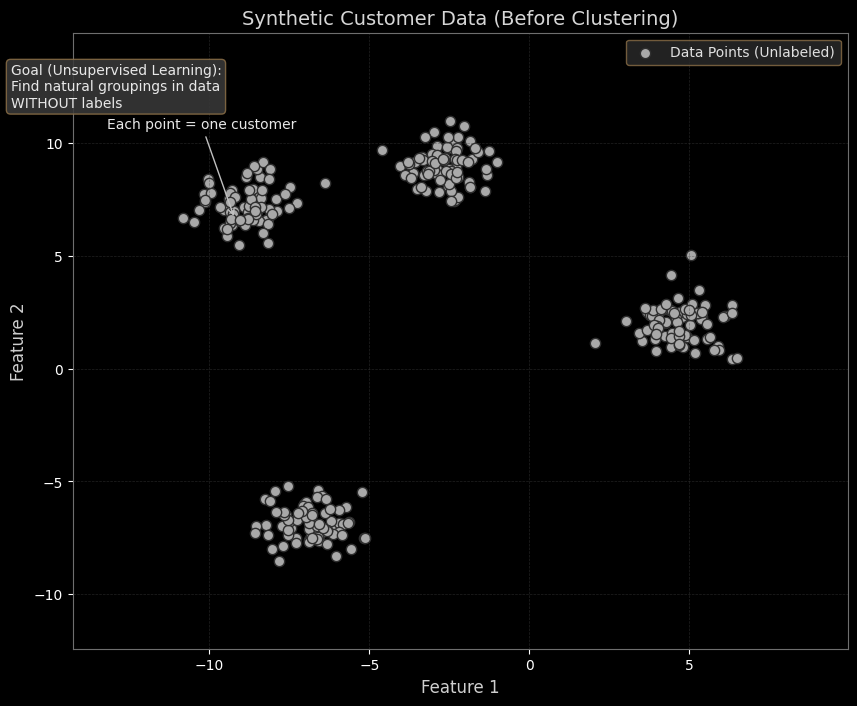

In [1]:
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs

plt.style.use('dark_background')

X, y = make_blobs(
    n_samples=300,
    centers=4,
    cluster_std=0.8,
    random_state=42
)

fig, ax = plt.subplots(figsize=(10, 8))

scatter = ax.scatter(
    X[:, 0],
    X[:, 1],
    s=55,
    color='#A9A9A9',
    edgecolor='#2F2F2F',
    label="Data Points (Unlabeled)"
)

ax.annotate(
    "Each point = one customer",
    xy=(X[0, 0], X[0, 1]),
    xytext=(X[0, 0] - 4, X[0, 1] + 4),
    arrowprops=dict(color='#C0C0C0', arrowstyle="->"),
    fontsize=10,
    color='#E8E8E8'
)

ax.text(
    -0.08, 0.95,
    "Goal (Unsupervised Learning):\nFind natural groupings in data\nWITHOUT labels",
    transform=ax.transAxes,
    fontsize=10,
    verticalalignment='top',
    bbox=dict(boxstyle="round", facecolor="#3A3A3A", edgecolor="#8B6F47", alpha=0.85),
    color="#E8E8E8"
)

ax.set_title("Synthetic Customer Data (Before Clustering)", fontsize=14, color="#D6D6D6")
ax.set_xlabel("Feature 1", fontsize=12, color="#CFCFCF")
ax.set_ylabel("Feature 2", fontsize=12, color="#CFCFCF")

legend = ax.legend(loc="upper right", facecolor="#2B2B2B", edgecolor="#8B6F47")
for text in legend.get_texts():
    text.set_color("#E0E0E0")

ax.grid(color="#444444", linestyle='--', linewidth=0.5, alpha=0.5)

for spine in ax.spines.values():
    spine.set_color("#6E6E6E")

# Zoom out by expanding axis limits
x_margin = (X[:, 0].max() - X[:, 0].min()) * 0.2
y_margin = (X[:, 1].max() - X[:, 1].min()) * 0.2

ax.set_xlim(X[:, 0].min() - x_margin, X[:, 0].max() + x_margin)
ax.set_ylim(X[:, 1].min() - y_margin, X[:, 1].max() + y_margin)

plt.show()

### Task 1: Find the Optimal Number of Clusters (The Elbow Method)
#### Concept:
How do we know what `k` should be? The **Elbow Method** helps us decide. We run K-Means for a range of `k` values and for each `k`, we calculate the **inertia** (the sum of squared distances of samples to their closest cluster center). We then plot the inertia for each `k`. The "elbow" of the curve—the point where the inertia starts to decrease much more slowly—is a good estimate for the optimal `k`.

#### Your Task:
Calculate and plot the inertia for `k` values from 1 to 10.

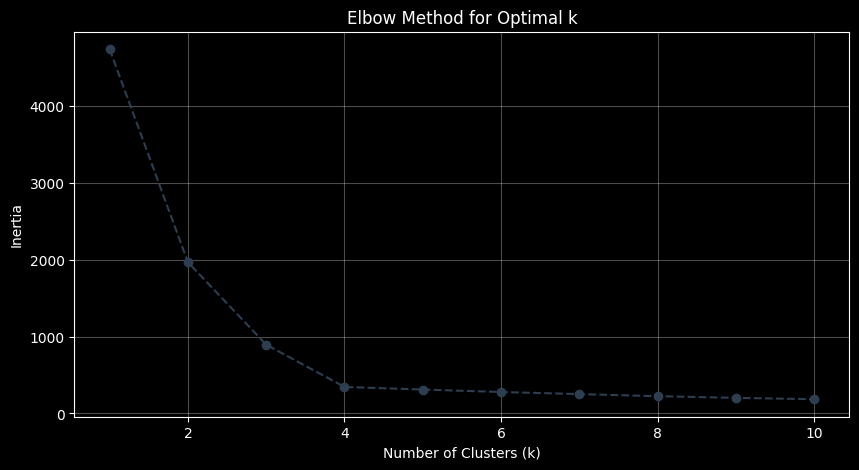

In [2]:
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.datasets import make_blobs

# Configuration for clean plotting
plt.rcParams['figure.figsize'] = [10, 5]
plt.rcParams['figure.dpi'] = 100

# Generate sample data
X, _ = make_blobs(n_samples=500, centers=4, cluster_std=0.60, random_state=0)

inertia = []
K_range = range(1, 11)

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X)
    inertia.append(kmeans.inertia_)

# Visualization of the Elbow Method
plt.plot(K_range, inertia, marker='o', linestyle='--', color='#2c3e50')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Inertia')
plt.title('Elbow Method for Optimal k')
plt.grid(True, alpha=0.3)
plt.show()

### Interpreting the Elbow Method Results
The **Elbow Method** helps determine the optimal number of clusters (`k`).

*   As `k` increases, **inertia** decreases.
*   However, after a certain point, the improvement in inertia slows down significantly.
*   This "bend" or "elbow" in the curve suggests the best `k` value.

In this case, the elbow appears around **k = 4**.

### Task 2: Perform K-Means Clustering and Visualize
From the elbow plot, it looks like `k=4` is the optimal number of clusters.

#### Your Task:
Run K-Means with `n_clusters=4` and create a scatter plot showing the data points colored by their assigned cluster.

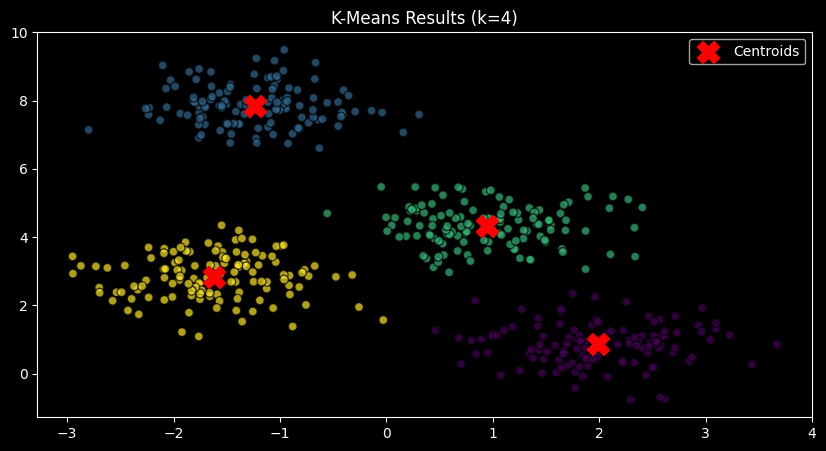

In [3]:
# Apply K-Means
kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
y_kmeans = kmeans.fit_predict(X)

# Visualize clusters with Centroids
plt.scatter(X[:, 0], X[:, 1], c=y_kmeans, s=40, cmap='viridis', edgecolors='k', alpha=0.7)
centers = kmeans.cluster_centers_
plt.scatter(centers[:, 0], centers[:, 1], c='red', s=250, marker='X', label='Centroids')
plt.title("K-Means Results (k=4)")
plt.legend()
plt.show()

### K-Means Clustering Results Summary
K-Means grouped the data into 4 clusters.

*   Each color represents a distinct **cluster**.
*   The **red X markers** represent the **centroids**, which are the centers of these clusters.
*   The algorithm assigns each data point to its nearest centroid.

This demonstrates how unsupervised learning identifies natural patterns and groups in data **without** needing pre-defined labels.

## Part 3: Principal Component Analysis (PCA)
### Concept:
**PCA** is a dimensionality reduction technique. It transforms the data into a new coordinate system of **principal components**. These components are orthogonal (uncorrelated) and are ordered by the amount of variance in the data they explain. By keeping only the first few principal components, we can reduce the number of dimensions in our data while losing as little information as possible.

### Use Cases:
*   **Visualization:** Reducing high-dimensional data to 2 or 3 dimensions so we can plot it.
*   **Performance:** Speeding up model training by using fewer features.

### Problem:
We will use the **Iris dataset**, which has 4 features, and reduce it to 2 features so we can visualize it.

### Task 3: Apply PCA to the Iris Dataset
#### Your Task:
Use `PCA` from `sklearn.decomposition` to reduce the 4-dimensional Iris dataset to 2 principal components and visualize the result.

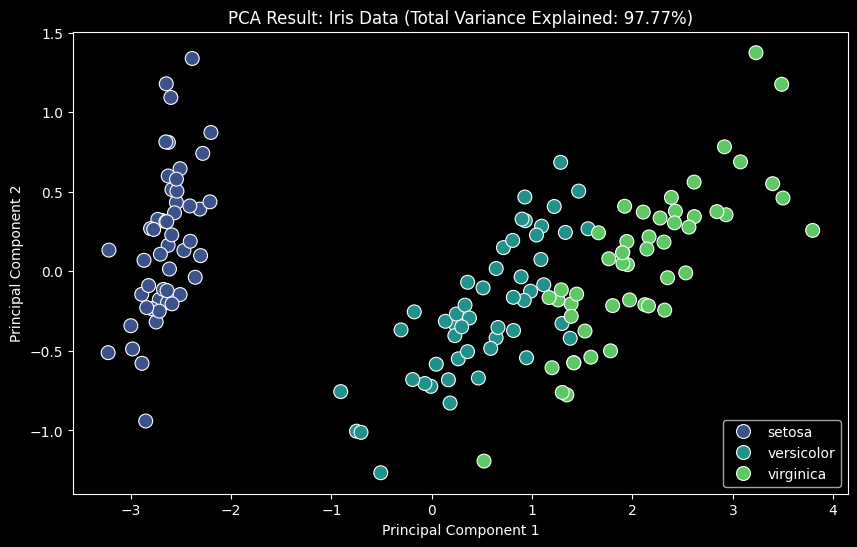

In [4]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA
from sklearn.datasets import load_iris

# Load Iris dataset
iris = load_iris()
pca = PCA(n_components=2)
X_pca = pca.fit_transform(iris.data)

# Visualization of PCA projection
plt.figure(figsize=(10, 6))
sns.scatterplot(x=X_pca[:, 0], y=X_pca[:, 1], hue=iris.target_names[iris.target],
                palette='viridis', s=100, edgecolor='w')
plt.title(f"PCA Result: Iris Data (Total Variance Explained: {sum(pca.explained_variance_ratio_):.2%})")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.show()

### PCA Results Summary
PCA successfully reduced the 4 features of the Iris dataset into 2 principal components.

*   These components capture most of the original variance in the data.
*   The data becomes much easier to visualize in two dimensions.
*   This technique is crucial for improving model performance and reducing complexity in high-dimensional datasets.

## 📝 Knowledge Check
**Instructions:** Answer the following questions in this markdown cell.

1.  **What is the fundamental difference between supervised and unsupervised learning?**

The fundamental distinction lies in the presence of a "ground truth" or teacher signal. Supervised learning acts like a student with an answer key; it maps inputs to known outputs. In contrast, unsupervised learning is like an explorer discovering the layout of a new territory without a map, identifying inherent structures based purely on the density and distribution of data points.

**Real-World Example:**

Supervised: A bank uses millions of transactions labeled "fraudulent" or "legitimate" to train a model that flags future suspicious activity.

Unsupervised: A retail company takes their entire customer database (without labels) and uses clustering to discover distinct groups, such as "High-Spend/Low-Frequency" shoppers versus "Budget/High-Frequency" shoppers, to tailor their marketing strategies.



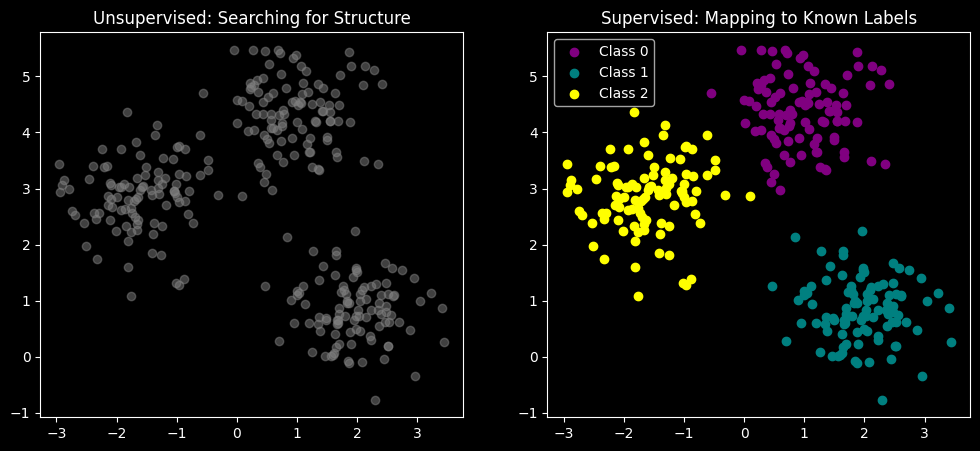

In [5]:
import matplotlib.pyplot as plt
import numpy as np

# Visualizing the difference: Labeled vs Unlabeled
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

# Unsupervised (Unlabeled)
X, _ = make_blobs(n_samples=300, centers=3, cluster_std=0.60, random_state=0)
ax1.scatter(X[:, 0], X[:, 1], c='gray', alpha=0.5)
ax1.set_title("Unsupervised: Searching for Structure")

# Supervised (Labeled)
X, y = make_blobs(n_samples=300, centers=3, cluster_std=0.60, random_state=0)
colors = ['purple', 'teal', 'yellow']
for i, color in enumerate(colors):
    ax2.scatter(X[y==i, 0], X[y==i, 1], c=color, label=f"Class {i}")
ax2.set_title("Supervised: Mapping to Known Labels")
ax2.legend()
plt.show()

2.  **In the K-Means elbow plot, why don't we just choose the largest possible `k` to get the lowest inertia?**

Selecting an excessively large $k$ results in overfitting, where the model captures noise rather than the underlying pattern. As $k$ increases, the inertia (error) naturally drops because centroids become closer to individual points. At the extreme ($k = N$), every data point is its own centroid, reducing error to zero but providing zero insight. A good model must simplify the data to be useful.Real-World Example:Imagine a clothing brand designing shirt sizes.Optimal k (e.g., k=5): You create S, M, L, XL, and XXL. These represent broad, useful clusters of body types.Too Large k (e.g., k=500): You create a unique shirt size for every single customer. While the "fit" is perfect (zero error), the manufacturing cost is astronomical and you can no longer predict what sizes to stock in a store for new customers.

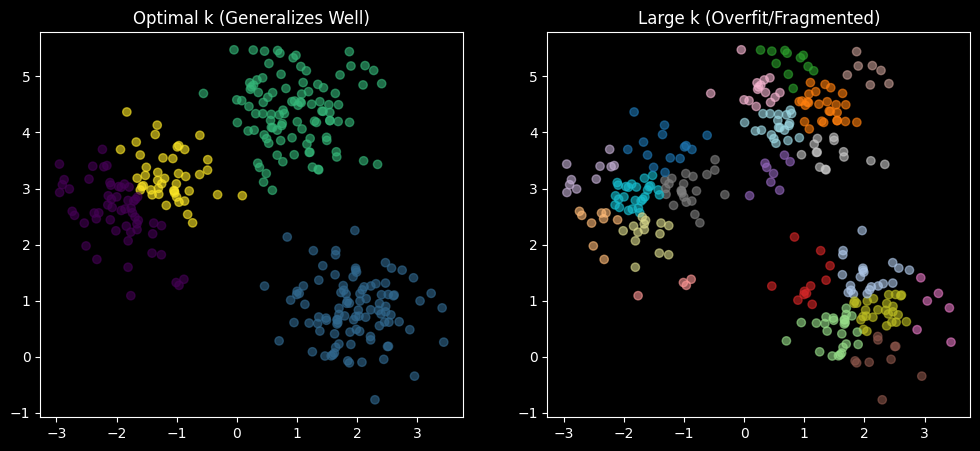

In [6]:
# Visualizing Overfitting in Clustering
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

# Optimal k=4
km_opt = KMeans(n_clusters=4, n_init=10).fit(X)
ax1.scatter(X[:, 0], X[:, 1], c=km_opt.labels_, cmap='viridis', alpha=0.6)
ax1.set_title("Optimal k (Generalizes Well)")

# Too Large k=20
km_high = KMeans(n_clusters=20, n_init=10).fit(X)
ax2.scatter(X[:, 0], X[:, 1], c=km_high.labels_, cmap='tab20', alpha=0.6)
ax2.set_title("Large k (Overfit/Fragmented)")
plt.show()

3.  **In the PCA results, the first two principal components explained over 95% of the variance. What does this tell you about the original 4-dimensional Iris dataset?**

This indicates "redundancy" or high correlation within the original features. When the first two components capture the vast majority of variance (e.g., >90%), it means the "essence" of the data exists on a 2D plane even if it was originally recorded in 10D or 100D. This allows for massive data compression and visualization without losing the critical "signal" of the dataset.

Real-World Example:
Consider describing a human's physical size using "Height," "Arm Length," "Leg Length," and "Torso Length." These four features are highly correlated (tall people generally have long limbs).

PCA Result: A single "Size" component might explain 95% of the variance. Instead of tracking four separate measurements, you can simplify your analysis to one primary component ("Overall Scale") and one secondary component ("Proportions") while still describing the person accurately.

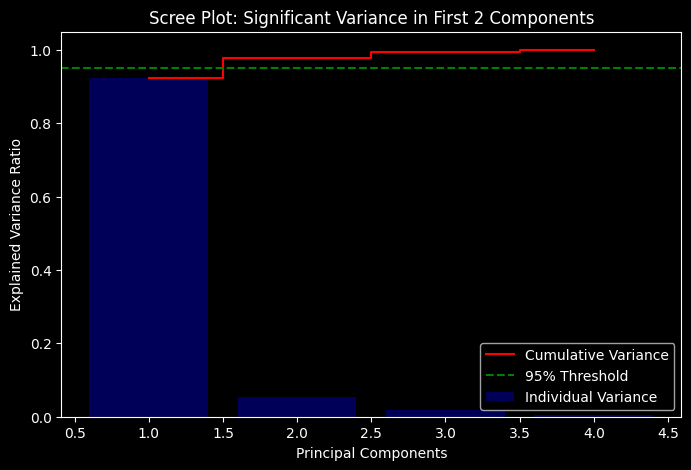

In [7]:
# Visualizing Variance Retention
pca_full = PCA().fit(iris.data)
plt.figure(figsize=(8, 5))
plt.bar(range(1, 5), pca_full.explained_variance_ratio_, alpha=0.7, color='navy', label='Individual Variance')
plt.step(range(1, 5), np.cumsum(pca_full.explained_variance_ratio_), where='mid', label='Cumulative Variance', color='red')
plt.ylabel('Explained Variance Ratio')
plt.xlabel('Principal Components')
plt.title('Scree Plot: Significant Variance in First 2 Components')
plt.axhline(y=0.95, color='green', linestyle='--', label='95% Threshold')
plt.legend()
plt.show()